## Import Libraries

In [12]:
import sys
from pathlib import Path

_src = str(Path('../../src').resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from config import get_base_dir, set_base_dir
from utils.matplotlib_config import register_matplotlib_setconfig
from analysis.mass_functions import smf_given_redshift_and_subvolume
from analysis import (
    smfs_given_redshifts_and_subvolume,
    avg_smf_given_redshifts_and_subvolume,
)

# Set the correct base directory
set_base_dir('/cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
base_dir = Path(get_base_dir())
register_matplotlib_setconfig(mpl)
mpl.setconfig()

## For a given redshift and sub volume, plot the SMF

In [13]:
example_snapshot = 'iz207'
example_ivol = 0
smf_result = smf_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    )

if smf_result is not None:
    z_val = smf_result.get('z')
    z_label = f"{z_val:.3f}" if z_val is not None else "n/a"
    V_ivol = smf_result.get('V_ivol')
    counts = smf_result['counts']
    print(f"Redshift z = {z_label}",
        f"Volume V_ivol = {V_ivol:.3e} Mpc^3" if V_ivol is not None else "Volume N/A",
        f"Total galaxies counted: {counts.sum()}")
else:
    print(f"Failed to load SMF for {example_snapshot}, ivol={example_ivol}")

Redshift z = n/a Volume V_ivol = 1.556e+05 Mpc^3 Total galaxies counted: 21211


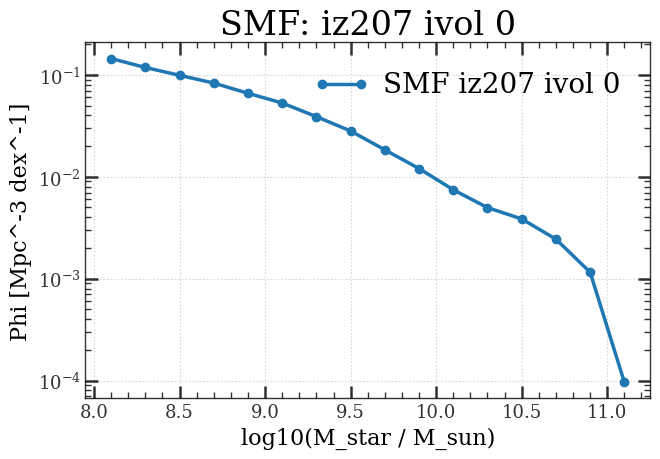

In [15]:
if smf_result is not None:
    centers = smf_result['centers']
    phi = smf_result['phi']
    valid = np.isfinite(phi) & (phi > 0)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_yscale('log')
    ax.plot(centers[valid], phi[valid], 'o-', label=f"SMF {example_snapshot} ivol {example_ivol}")
    ax.set_xlabel("log10(M_star / M_sun)")
    ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
    ax.set_title(f"SMF: {example_snapshot} ivol {example_ivol}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: smf_result is None")

## For a given redshift and subvolume, compare to observational SMFs

In [7]:
example_snapshot = 'iz207'
example_ivol = 40
smf_comp_data = smf_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    )

if smf_comp_data is not None:
    z_val = smf_comp_data.get('z')
    V_ivol = smf_comp_data.get('V_ivol')
    counts = smf_comp_data['counts']
    z_str = f"{z_val:.3f}" if z_val is not None else "N/A"
    V_str = f"{V_ivol:.3e}" if V_ivol is not None else "N/A"
    print(f"Redshift z = {z_str}",
        f"Volume V_ivol = {V_str} Mpc^3",
        f"Total galaxies counted: {counts.sum()}")
else:
    print(f"Failed to load SMF for {example_snapshot}, ivol={example_ivol}")

Redshift z = N/A Volume V_ivol = 1.556e+05 Mpc^3 Total galaxies counted: 21274


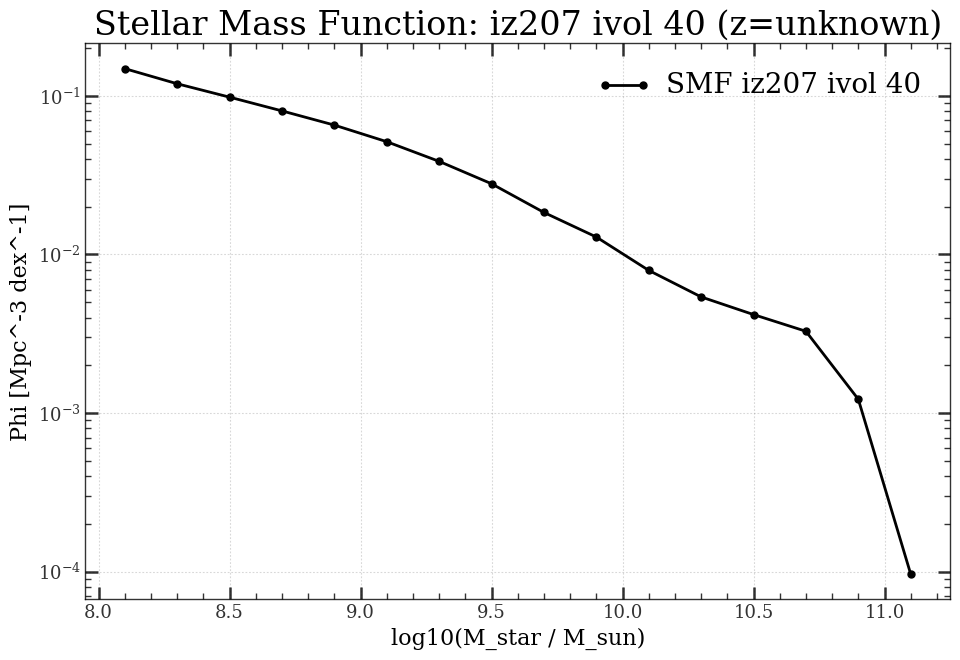

Loaded 22 mass bins Redshift: z = unknown Volume: V = 1.56e+05 (Mpc/h)^3


In [9]:
if smf_comp_data is not None:
    centers = smf_comp_data['centers']
    phi = smf_comp_data['phi']
    valid = np.isfinite(phi) & (phi > 0)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_yscale('log')
    ax.plot(centers[valid], phi[valid], 'o-', label=f"SMF {example_snapshot} ivol {example_ivol}",
            linewidth=2, markersize=5, color='black', zorder=10)
    ax.set_xlabel("log10(M_star / M_sun)")
    ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
    title = f"Stellar Mass Function: {example_snapshot} ivol {example_ivol}"
    z_val = smf_comp_data.get('z')
    z_str = f"{z_val:.2f}" if z_val is not None else "unknown"
    title += f" (z={z_str})"
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    V_ivol = smf_comp_data.get('V_ivol')
    V_str = f"{V_ivol:.2e}" if V_ivol is not None else "N/A"
    print(f"Loaded {len(centers)} mass bins",
        f"Redshift: z = {z_str}",
        f"Volume: V = {V_str} (Mpc/h)^3")
else:
    print("Cannot plot: smf_comp_data is None")

## SMFs for different redshifts

In [ ]:
example_ivol = 8
iz_nums = [155, 175, 207]  # subset for faster testing

multi_smf_result = smfs_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    base_dir=base_dir,
    )

if multi_smf_result is not None:
    smf_df, results_by_z = multi_smf_result
    print(f"Loaded {len(results_by_z)} snapshots for ivol={example_ivol}")
else:
    print(f"Failed to load SMFs for ivol={example_ivol}")
    results_by_z = []

Loaded 1 snapshots for ivol=8


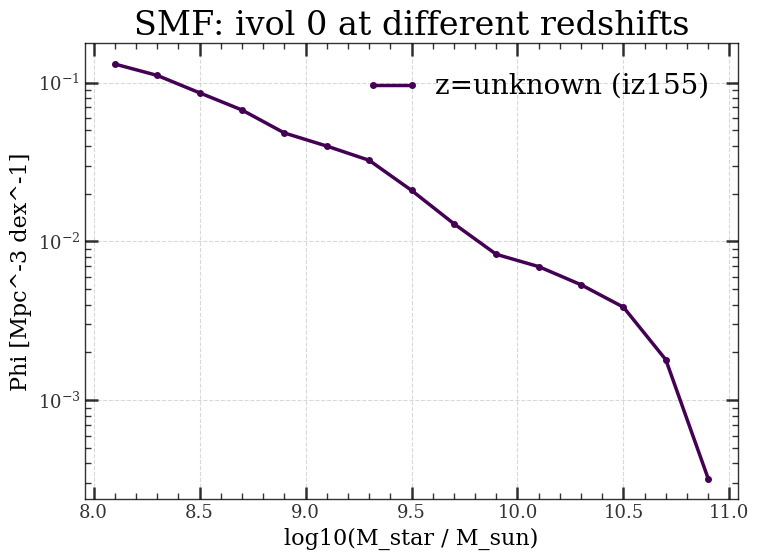

In [14]:
if results_by_z:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_yscale('log')
    colors = plt.cm.viridis(np.linspace(0, 1, len(results_by_z)))
    for res, color in zip(results_by_z, colors):
        centers = res['centers']
        phi = res['phi']
        valid = np.isfinite(phi) & (phi > 0)
        z = res.get('z')
        z_str = f"{z:.2f}" if z is not None else "unknown"
        ax.plot(centers[valid], phi[valid], 'o-', label=f"z={z_str} ({res['iz']})", color=color, markersize=4)
    ax.set_xlabel("log10(M_star / M_sun)")
    ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
    ax.set_title(f"SMF: ivol {example_ivol} at different redshifts")
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: results_by_z is empty")

## For a given sub volume average over given redshifts

In [16]:
example_ivol = 1  # choose a subvolume
iz_nums = [155, 175, 207]  # snapshots that exist in base_dir

avg_smf_result = avg_smf_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    )

if avg_smf_result is not None:
    n_used = avg_smf_result.get('n_used')
    n_requested = avg_smf_result.get('n_requested')
    iz_list = avg_smf_result.get('iz_list', [])
    z_list = avg_smf_result.get('z_list', [])
    z_list_valid = [z for z in z_list if z is not None]
    z_strs = [f'{z:.2f}' for z in z_list_valid] if z_list_valid else ["N/A"]
    print(f"Successfully used {n_used}/{n_requested} snapshots",
        f"Snapshots: {iz_list}",
        f"Redshifts: {z_strs}")
else:
    print(f"Failed to compute average SMF")
    avg_smf_result = {}

Successfully used 2/3 snapshots Snapshots: ['iz155', 'iz207'] Redshifts: ['N/A']


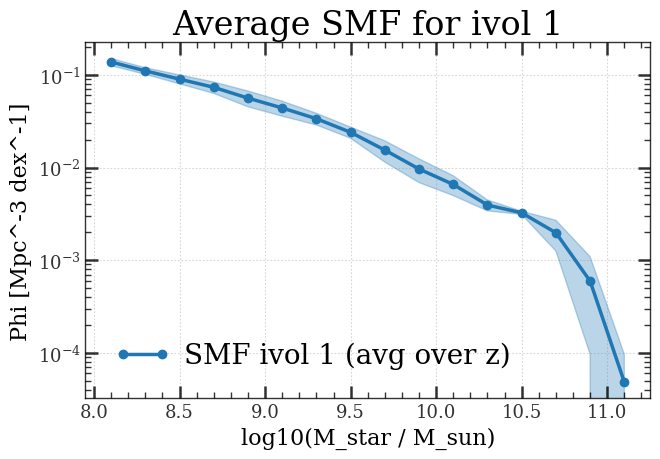

In [17]:
if avg_smf_result and 'centers' in avg_smf_result:
    centers = avg_smf_result['centers']
    phi = avg_smf_result['phi']
    phi_std = avg_smf_result['phi_std']
    valid = np.isfinite(phi) & (phi > 0)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_yscale('log')
    ax.plot(centers[valid], phi[valid], 'o-', label=f"SMF ivol {avg_smf_result['ivol']} (avg over z)", color='C0')
    ax.fill_between(centers[valid], (phi - phi_std)[valid], (phi + phi_std)[valid], alpha=0.3, color='C0')
    ax.set_xlabel("log10(M_star / M_sun)")
    ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
    ax.set_title(f"Average SMF for ivol {avg_smf_result['ivol']}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: avg_smf_result is empty or missing required data")